In [1]:
import json

from ortools.linear_solver import pywraplp

In [2]:
with open("../data/animal_with_pickups.json", "r") as f:
    animals = json.load(f)

with open("../data/crop_rollouts.json", "r") as f:
    crops = json.load(f)

with open("../data/handmade_dp_candidates.json", "r") as f:
    candidates = json.load(f)

In [3]:
animal_profiles = {f"{animal}_with_care": animals["animals"][animal]["with_care"] for animal in animals["animals"]}
crop_profiles = {f"{crop}_no_fert": crops["crops"][crop]["no_fert"] for crop in crops["crops"]}

profiles = {**animal_profiles, **crop_profiles}

In [4]:
prices = {}
for animal in animals["animals"]:
    prices[f"{animal}_with_care"] = animals["animals"][animal]["base_price"]
for crop in crops["crops"]:
    prices[f"{crop}_no_fert"] = crops["crops"][crop]["base_price"]

costs = {}
for animal in animals["animals"]:
    costs[f"{animal}_with_care"] = animals["animals"][animal]["animal_cost"]
for crop in crops["crops"]:
    costs[f"{crop}_no_fert"] = crops["crops"][crop]["seed_cost"]

prices, costs

({'GOOSE_with_care': 50,
  'COW_with_care': 160,
  'SHEEP_with_care': 200,
  'WHEAT_no_fert': 25,
  'CARROT_no_fert': 35,
  'MELON_no_fert': 250,
  'TOMATO_no_fert': 60,
  'STRAWBERRY_no_fert': 120},
 {'GOOSE_with_care': 300,
  'COW_with_care': 400,
  'SHEEP_with_care': 500,
  'WHEAT_no_fert': 10,
  'CARROT_no_fert': 20,
  'MELON_no_fert': 80,
  'TOMATO_no_fert': 50,
  'STRAWBERRY_no_fert': 100})

In [5]:
for profile, data in profiles.items():
    print(profile, data.keys())

GOOSE_with_care dict_keys(['days', 'harvest_ages', 'yield_per_harvest', 'expected_yield'])
COW_with_care dict_keys(['days', 'harvest_ages', 'yield_per_harvest', 'expected_yield'])
SHEEP_with_care dict_keys(['days', 'harvest_ages', 'yield_per_harvest', 'expected_yield'])
WHEAT_no_fert dict_keys(['days', 'harvest_ages', 'yield_per_harvest', 'tile_free_age', 'expected_yield', 'fertilize_ages'])
CARROT_no_fert dict_keys(['days', 'harvest_ages', 'yield_per_harvest', 'tile_free_age', 'expected_yield', 'fertilize_ages'])
MELON_no_fert dict_keys(['days', 'harvest_ages', 'yield_per_harvest', 'tile_free_age', 'expected_yield', 'fertilize_ages'])
TOMATO_no_fert dict_keys(['days', 'harvest_ages', 'yield_per_harvest', 'tile_free_age', 'expected_yield', 'fertilize_ages'])
STRAWBERRY_no_fert dict_keys(['days', 'harvest_ages', 'yield_per_harvest', 'tile_free_age', 'expected_yield', 'fertilize_ages'])


In [6]:
for profile, data in profiles.items():
    data["timeline_ops_count"] = [0 for _ in range(len(data["days"]))]
    data["timeline_values"] = [0 for _ in range(len(data["days"]))]
    harvest_map = dict(zip(data["harvest_ages"], data["yield_per_harvest"]))

    for day_spec in data["days"]:
        age = day_spec["age"]
        data["timeline_ops_count"][age] = len(day_spec["actions"])
        for action in day_spec["actions"]:
            if action == "HARVEST":
                data["timeline_values"][age] += prices[profile] * harvest_map[age]
            elif action in ["BUILD_COOP", "BUILD_PASTURE", "PLANT"]:
                data["timeline_values"][age] -= costs[profile]

In [7]:
profiles["WHEAT_no_fert"]["timeline_ops_count"], profiles["WHEAT_no_fert"]["timeline_values"]

([2, 1, 1, 1, 2], [-10, 0, 0, 0, 100])

In [8]:
profiles

{'GOOSE_with_care': {'days': [{'age': 0,
    'actions': ['PICKUP', 'PICKUP', 'BUILD_COOP', 'PLACE', 'FEED', 'CARE']},
   {'age': 1, 'actions': ['PICKUP', 'FEED', 'CARE', 'COLLECT_FERTILIZER']},
   {'age': 2, 'actions': ['PICKUP', 'FEED', 'CARE', 'COLLECT_FERTILIZER']},
   {'age': 3, 'actions': ['PICKUP', 'FEED', 'CARE', 'COLLECT_FERTILIZER']},
   {'age': 4,
    'actions': ['PICKUP', 'FEED', 'CARE', 'HARVEST', 'COLLECT_FERTILIZER']},
   {'age': 5,
    'actions': ['PICKUP', 'FEED', 'CARE', 'HARVEST', 'COLLECT_FERTILIZER']},
   {'age': 6,
    'actions': ['PICKUP', 'FEED', 'CARE', 'HARVEST', 'COLLECT_FERTILIZER']},
   {'age': 7,
    'actions': ['PICKUP', 'FEED', 'CARE', 'HARVEST', 'COLLECT_FERTILIZER']},
   {'age': 8,
    'actions': ['PICKUP', 'FEED', 'CARE', 'HARVEST', 'COLLECT_FERTILIZER']},
   {'age': 9,
    'actions': ['PICKUP', 'FEED', 'CARE', 'HARVEST', 'COLLECT_FERTILIZER']},
   {'age': 10,
    'actions': ['PICKUP', 'FEED', 'CARE', 'HARVEST', 'COLLECT_FERTILIZER']},
   {'age': 11,
 

In [9]:
candidate_values = []
horizon = 30  # calendar days 0..29; animal profiles are 30 ages

for candidate in candidates:
    total = 0
    for profile, start in candidate:
        values = profiles[profile]["timeline_values"]
        total += sum(values[: horizon - start])
    candidate_values.append(total)

len(candidate_values)

108

In [10]:
horizon = 30
ZONES = {
    "farmer": {"tiles": list(range(0, 9)), "cap": 15},
    "hire1": {"tiles": list(range(9, 15)), "cap": 13},
    "hire2": {"tiles": list(range(15, 21)), "cap": 13},
    "hire3": {"tiles": list(range(21, 25)), "cap": 11},
}


def candidate_daily_vectors(candidate):
    ops = [0] * horizon
    cash = [0] * horizon
    feed = [0] * horizon
    wheat = [0] * horizon
    fert = [0] * horizon
    collect = [0] * horizon
    for profile_key, start in candidate:
        pdata = profiles[profile_key]
        harvest_map = dict(zip(pdata["harvest_ages"], pdata["yield_per_harvest"]))
        is_wheat = profile_key.startswith("WHEAT_")
        for day_spec in pdata["days"]:
            age = day_spec["age"]
            cal = start + age
            if cal >= horizon:
                continue
            acts = day_spec["actions"]
            ops[cal] += len(acts)
            cash[cal] += pdata["timeline_values"][age]
            if "FEED" in acts:
                feed[cal] += 1
            if "FERTILIZE" in acts:
                fert[cal] += 1
            if "COLLECT_FERTILIZER" in acts:
                collect[cal] += 1
            if is_wheat and "HARVEST" in acts and age in harvest_map:
                wheat[cal] += harvest_map[age]
    return ops, cash, feed, wheat, fert, collect


candidate_ops = []
candidate_cash = []
candidate_feed = []
candidate_wheat = []
candidate_fert = []
candidate_collect = []
for candidate in candidates:
    ops, cash, feed, wheat, fert, collect = candidate_daily_vectors(candidate)
    candidate_ops.append(ops)
    candidate_cash.append(cash)
    candidate_feed.append(feed)
    candidate_wheat.append(wheat)
    candidate_fert.append(fert)
    candidate_collect.append(collect)

# idle: zero ops, zero cash, zero value
candidates.append([])
candidate_ops.append([0] * horizon)
candidate_cash.append([0] * horizon)
candidate_feed.append([0] * horizon)
candidate_wheat.append([0] * horizon)
candidate_fert.append([0] * horizon)
candidate_collect.append([0] * horizon)
candidate_values.append(0)

num_candidates = len(candidates)
print(f"{num_candidates - 1} handmade candidates + 1 idle -> {num_candidates} catalog entries")


108 handmade candidates + 1 idle -> 109 catalog entries


In [11]:
# Create the mip solver with the SCIP backend.
solver = pywraplp.Solver.CreateSolver("SCIP")

if not solver:
    assert False, "No solver found"

In [12]:
num_days = horizon
start_money = 3000

# count[zone][i]: how many tiles in zone run candidate i
count = {}
for zone, spec in ZONES.items():
    zsize = len(spec["tiles"])
    count[zone] = [
        solver.IntVar(0, zsize, f"n_{zone}_{i}") for i in range(num_candidates)
    ]
    solver.Add(solver.Sum(count[zone]) == zsize)

print(f"decision vars: {num_candidates} candidates x {len(ZONES)} zones = {num_candidates * len(ZONES)}")

decision vars: 109 candidates x 4 zones = 436


In [13]:
# Per-zone daily ops caps
for day in range(num_days):
    for zone, spec in ZONES.items():
        terms = []
        for i in range(num_candidates):
            n_ops = candidate_ops[i][day]
            if n_ops:
                terms.append(count[zone][i] * n_ops)
        if terms:
            solver.Add(solver.Sum(terms) <= spec["cap"])

In [14]:
# Open wheat / fertilizer: buy shortfall at fixed I0 prices
WHEAT_PRICE = 25
FERT_PRICE = 100
HIRE_DAILY_COST = 4
MAX_BUY = 25 * 30

W = [solver.IntVar(0, MAX_BUY, f"W_{d}") for d in range(num_days + 1)]
F = [solver.IntVar(0, MAX_BUY, f"F_{d}") for d in range(num_days + 1)]
solver.Add(W[0] == 0)
solver.Add(F[0] == 0)

buy_w = []
buy_f = []
for day in range(num_days):
    feed_terms = []
    fert_terms = []
    collect_terms = []
    wheat_terms = []
    for zone in ZONES:
        for i in range(num_candidates):
            if candidate_feed[i][day]:
                feed_terms.append(count[zone][i] * candidate_feed[i][day])
            if candidate_fert[i][day]:
                fert_terms.append(count[zone][i] * candidate_fert[i][day])
            if candidate_collect[i][day]:
                collect_terms.append(count[zone][i] * candidate_collect[i][day])
            if candidate_wheat[i][day]:
                wheat_terms.append(count[zone][i] * candidate_wheat[i][day])

    feed_d = solver.Sum(feed_terms) if feed_terms else 0
    fert_d = solver.Sum(fert_terms) if fert_terms else 0
    collect_d = solver.Sum(collect_terms) if collect_terms else 0
    wheat_d = solver.Sum(wheat_terms) if wheat_terms else 0

    bw = solver.IntVar(0, MAX_BUY, f"buy_w_{day}")
    bf = solver.IntVar(0, MAX_BUY, f"buy_f_{day}")
    buy_w.append(bw)
    buy_f.append(bf)

    solver.Add(W[day] >= feed_d)
    solver.Add(F[day] >= fert_d)
    solver.Add(W[day + 1] == W[day] - feed_d + wheat_d + bw)
    solver.Add(F[day + 1] == F[day] - fert_d + collect_d + bf)

# Cash-on-hand: daily balance chain (non-negative every day)
balance = []
for day in range(num_days):
    day_terms = []
    for zone in ZONES:
        for i in range(num_candidates):
            c = candidate_cash[i][day]
            if c:
                day_terms.append(count[zone][i] * c)
    day_terms.append(-WHEAT_PRICE * buy_w[day])
    day_terms.append(-FERT_PRICE * buy_f[day])
    day_terms.append(-HIRE_DAILY_COST)

    bal = solver.IntVar(0, 200_000, f"balance_{day}")
    net = solver.Sum(day_terms) if day_terms else 0
    if day == 0:
        solver.Add(bal == start_money + net)
    else:
        solver.Add(bal == balance[-1] + net)
    balance.append(bal)

In [15]:
# Add objective: chain value minus market wheat/fert purchases
objective = solver.Objective()
for zone in ZONES:
    for i in range(num_candidates):
        if candidate_values[i]:
            objective.SetCoefficient(count[zone][i], candidate_values[i])
for day in range(num_days):
    objective.SetCoefficient(buy_w[day], -WHEAT_PRICE)
    objective.SetCoefficient(buy_f[day], -FERT_PRICE)
objective.SetMaximization()


In [16]:
# solver.SetTimeLimit(10_000)
# solver.SetSolverSpecificParametersAsString("limits/gap=0.15")
# solver.SetSolverSpecificParametersAsString("limits/absgap=1000")
solver.SetNumThreads(8)

True

In [17]:
import time

t0 = time.perf_counter()
status = solver.Solve()
elapsed = time.perf_counter() - t0

print(f"status={status}, vars={solver.NumVariables()}, time={elapsed:.2f}s")
print(f"objective={solver.Objective().Value()}")

status=0, vars=588, time=16.73s
objective=83910.0


In [18]:
# Decode counts -> physical tiles (sorted tile ID within each zone)
selected = []
for zone, spec in ZONES.items():
    remaining = list(spec["tiles"])
    for i, candidate in enumerate(candidates):
        n = int(count[zone][i].solution_value())
        for _ in range(n):
            tile = remaining.pop(0)
            selected.append({"tile": tile, "zone": zone, "idx": i, "candidate": candidate})
selected.sort(key=lambda row: row["tile"])

print(f"n tiles assigned: {len(selected)}")
for row in selected:
    if not row["candidate"]:
        print(f"  tile={row['tile']:2d} {row['zone']:6s} IDLE")
        continue
    placements = ", ".join(f"{p}@{s}" for p, s in row["candidate"])
    print(
        f"  tile={row['tile']:2d} {row['zone']:6s} C{row['idx']:3d} "
        f"value={candidate_values[row['idx']]:.0f}  [{placements}]"
    )

min_bal = min(b.solution_value() for b in balance)
total_wheat_buy = sum(int(bw.solution_value()) for bw in buy_w)
total_fert_buy = sum(int(bf.solution_value()) for bf in buy_f)
print(f"\ncash floor (model balances): {min_bal:.0f}")
print(f"Total wheat buy: {total_wheat_buy} units ({total_wheat_buy * WHEAT_PRICE:.0f} coins)")
print(f"Total fert buy:  {total_fert_buy} units ({total_fert_buy * FERT_PRICE:.0f} coins)")

n tiles assigned: 25
  tile= 0 farmer C 16 value=2930  [MELON_no_fert@0, MELON_no_fert@11, WHEAT_no_fert@23]
  tile= 1 farmer C 20 value=2930  [MELON_no_fert@0, MELON_no_fert@12, WHEAT_no_fert@24]
  tile= 2 farmer C 22 value=2930  [MELON_no_fert@1, MELON_no_fert@13, WHEAT_no_fert@25]
  tile= 3 farmer C 22 value=2930  [MELON_no_fert@1, MELON_no_fert@13, WHEAT_no_fert@25]
  tile= 4 farmer C 25 value=3010  [CARROT_no_fert@0, MELON_no_fert@4, MELON_no_fert@15, CARROT_no_fert@26]
  tile= 5 farmer C 28 value=2930  [WHEAT_no_fert@0, MELON_no_fert@6, MELON_no_fert@18]
  tile= 6 farmer C 28 value=2930  [WHEAT_no_fert@0, MELON_no_fert@6, MELON_no_fert@18]
  tile= 7 farmer C 28 value=2930  [WHEAT_no_fert@0, MELON_no_fert@6, MELON_no_fert@18]
  tile= 8 farmer C 58 value=5590  [WHEAT_no_fert@0, SHEEP_with_care@5]
  tile= 9 hire1  C 18 value=2930  [MELON_no_fert@0, MELON_no_fert@10, WHEAT_no_fert@22]
  tile=10 hire1  C 26 value=3015  [WHEAT_no_fert@0, MELON_no_fert@4, MELON_no_fert@14, CARROT_no_fer

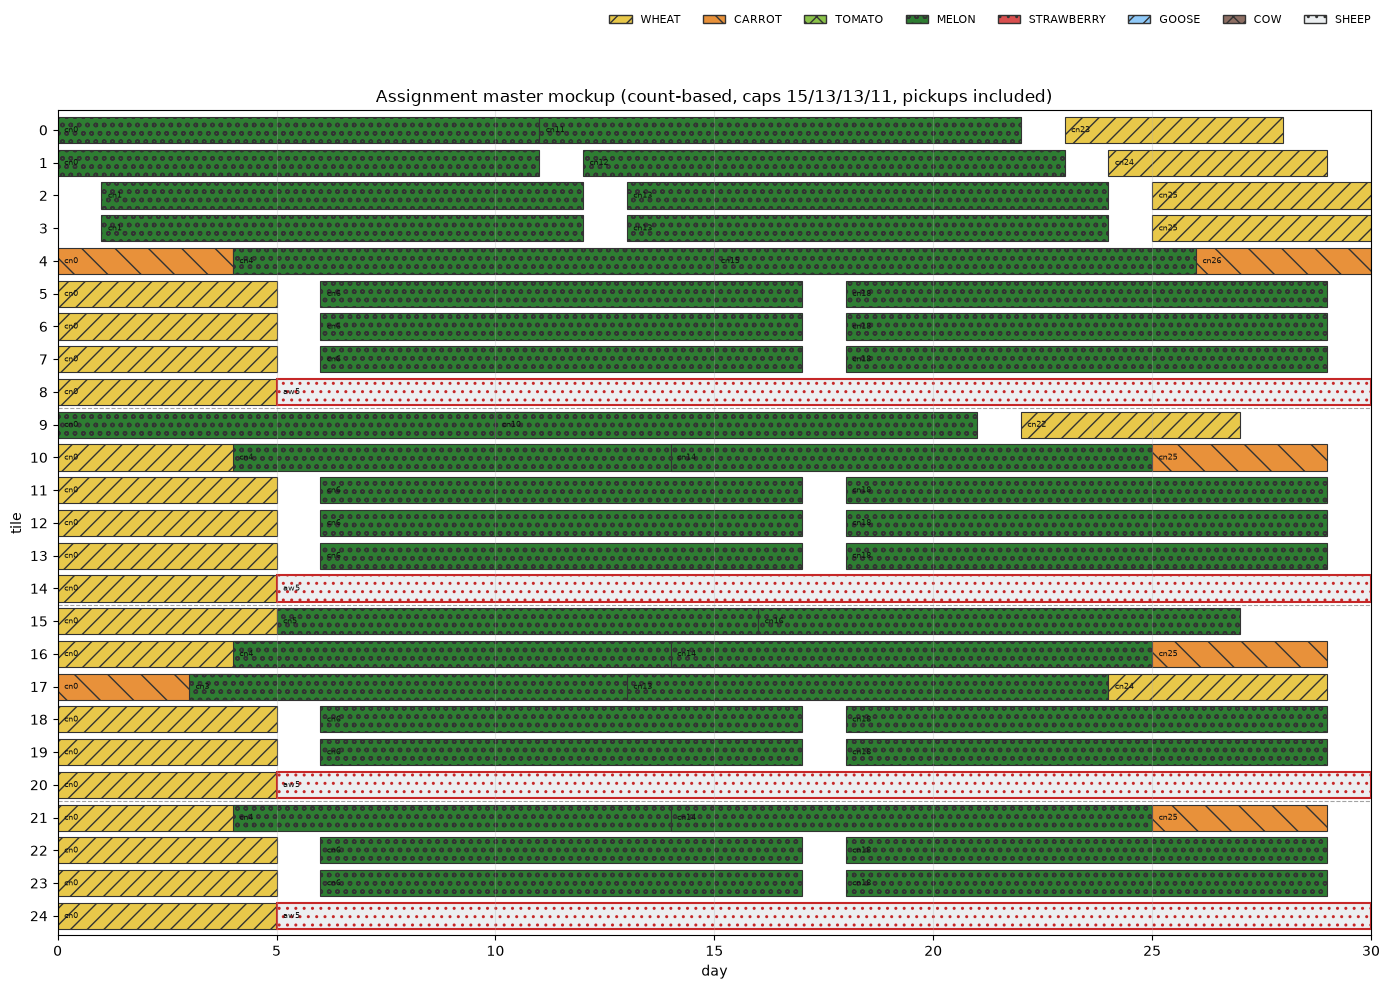

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

NUM_TILES = 25
PROFILE_SUFFIXES = ("no_fert", "with_fert", "no_care", "with_care")

CROP_STYLE = {
    "WHEAT": {"color": "#e8c84a", "hatch": "//"},
    "CARROT": {"color": "#e8913a", "hatch": "\\"},
    "TOMATO": {"color": "#8bc34a", "hatch": "xx"},
    "MELON": {"color": "#2e7d32", "hatch": "oo"},
    "STRAWBERRY": {"color": "#d94f4f", "hatch": ".."},
}
ANIMAL_STYLE = {
    "GOOSE": {"color": "#90caf9", "hatch": "//"},
    "COW": {"color": "#8d6e63", "hatch": "xx"},
    "SHEEP": {"color": "#eceff1", "hatch": ".."},
}


def parse_profile_key(profile_key):
    for suffix in PROFILE_SUFFIXES:
        token = f"_{suffix}"
        if profile_key.endswith(token):
            return profile_key[: -len(token)], suffix
    raise ValueError(f"unknown profile key: {profile_key}")


def placement_segment(profile_key, start_day):
    label, profile_name = parse_profile_key(profile_key)
    profile = profiles[profile_key]
    kind = "crop" if profile_name.endswith("fert") else "animal"
    occupied = []
    for day in profile["days"]:
        cal = start_day + day["age"]
        if cal >= horizon:
            if kind == "crop":
                return None
            break
        occupied.append(cal)
    if not occupied:
        return None
    return {
        "kind": kind,
        "label": label,
        "profile": profile_name,
        "profile_key": profile_key,
        "start_day": start_day,
        "end_day": max(occupied) + 1,
    }


def bar_style(segment):
    if segment["kind"] == "crop":
        st = dict(CROP_STYLE.get(segment["label"], {"color": "#999999", "hatch": ""}))
    else:
        st = dict(ANIMAL_STYLE.get(segment["label"], {"color": "#999999", "hatch": ""}))
    if segment["profile"] in ("with_fert", "with_care"):
        st["edgecolor"] = "#1565c0" if segment["kind"] == "crop" else "#c62828"
        st["linewidth"] = 1.5
    else:
        st.setdefault("edgecolor", "#333333")
        st.setdefault("linewidth", 0.8)
    return st


for row in selected:
    if not row["candidate"]:
        row["segments"] = []
        continue
    row["segments"] = [
        seg
        for profile_key, start_day in row["candidate"]
        if (seg := placement_segment(profile_key, start_day))
    ]


fig, ax = plt.subplots(figsize=(14, 10))
for row in selected:
    tile = row["tile"]
    for seg in row["segments"]:
        st = bar_style(seg)
        ax.barh(
            y=tile,
            width=seg["end_day"] - seg["start_day"],
            left=seg["start_day"],
            height=0.8,
            color=st["color"],
            hatch=st["hatch"],
            edgecolor=st["edgecolor"],
            linewidth=st["linewidth"],
        )
        tag = f"{seg['kind'][0]}{seg['profile'][0]}{seg['start_day']}"
        ax.text(seg["start_day"] + 0.15, tile, tag, va="center", fontsize=6, color="#111")

for yline in (8.5, 14.5, 20.5):
    ax.axhline(yline, color="#666666", linewidth=0.8, linestyle="--", alpha=0.6)

ax.set_xlabel("day")
ax.set_ylabel("tile")
ax.set_yticks(range(NUM_TILES))
ax.set_xlim(0, horizon)
ax.set_ylim(-0.6, NUM_TILES - 0.4)
ax.set_title("Assignment master mockup (count-based, caps 15/13/13/11, pickups included)")
ax.invert_yaxis()
legend_handles = [
    Patch(facecolor=st["color"], hatch=st["hatch"], edgecolor="#333333", label=name)
    for name, st in {**CROP_STYLE, **ANIMAL_STYLE}.items()
]
ax.grid(axis="x", alpha=0.3)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    bbox_transform=fig.transFigure,
    ncol=len(legend_handles),
    fontsize=8,
    frameon=False,
)
plt.show()